(6880, 117)
Aplikujem IntervalTransformer na df_clean...
[IntervalTransformer] Nájdené stĺpce na konverziu na čísla: ['d_d_age', 'd_importance_same_race', 'd_importance_same_religion', 'd_pref_o_attractive', 'd_pref_o_sincere', 'd_pref_o_intelligence', 'd_pref_o_funny', 'd_pref_o_ambitious', 'd_pref_o_shared_interests', 'd_attractive_o', 'd_sinsere_o', 'd_intelligence_o', 'd_funny_o', 'd_ambitous_o', 'd_shared_interests_o', 'd_attractive_important', 'd_sincere_important', 'd_intellicence_important', 'd_funny_important', 'd_ambtition_important', 'd_shared_interests_important', 'd_attractive', 'd_sincere', 'd_intelligence', 'd_funny', 'd_ambition', 'd_attractive_partner', 'd_sincere_partner', 'd_intelligence_partner', 'd_funny_partner', 'd_ambition_partner', 'd_shared_interests_partner', 'd_sports', 'd_tvsports', 'd_exercise', 'd_dining', 'd_museums', 'd_art', 'd_hiking', 'd_gaming', 'd_clubbing', 'd_reading', 'd_tv', 'd_theater', 'd_movies', 'd_concerts', 'd_music', 'd_shopping', 'd_yog

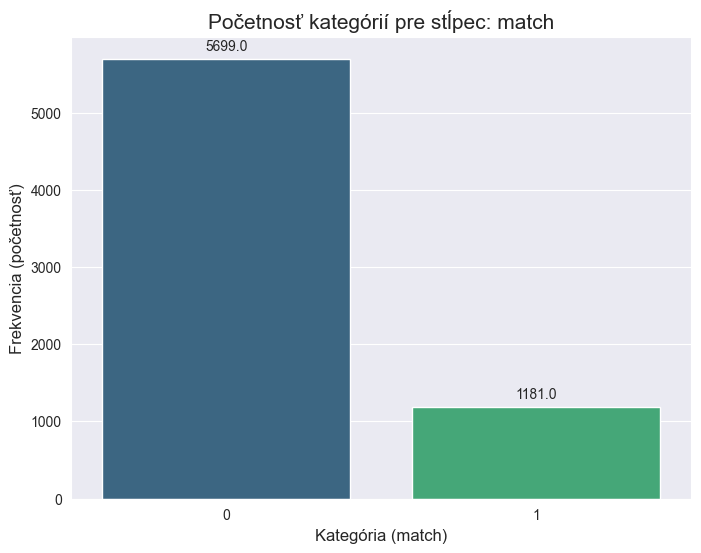

Tréningová množina: 4815 vzoriek
Validačná množina: 1033 vzoriek
Testovacia množina: 1032 vzoriek


wandb: Currently logged in as: xkmetk (xkmetk-slovak-technical-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Počet príznakov na vstupe do modelu: 126

--- Spúšťam experiment 1/3: current_best_adam_pos_weight3 ---
Používam pos_weight: 3.0


Test F1: 0.5575 | Test LogLoss: 0.4630 | Test Acc: 0.8324
Test Confusion Matrix:
[[750 105]
 [ 68 109]]
Test Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.88      0.90       855
           1       0.51      0.62      0.56       177

    accuracy                           0.83      1032
   macro avg       0.71      0.75      0.73      1032
weighted avg       0.85      0.83      0.84      1032



best_epoch,▁
dur,▁▁▂▂▃▁▁▂▁▂▃▅█▃▅
test_accuracy,▁
test_f1,▁
test_logloss,▁
train_loss,█▆▅▅▄▄▄▃▃▂▂▂▂▁▁
training_time_s,▁
val_f1,▁▂▃▆▄█▃▅▂▆▆▅▃▆█
valid_acc,▁▃▄▅▆▇▅▆▅▆▇▇▅▇█
valid_loss,▂▁▁▁▁▂▂▃▃▃▅▆▆▆█
best_epoch,16


...

best_epoch,▁
dur,█▅▆▆▂▅▁▂▅▁▇
test_accuracy,▁
test_f1,▁
test_logloss,▁
train_loss,█▆▅▄▄▃▃▂▂▂▁
training_time_s,▁
val_f1,▇█▇▃▆▇▁▄▃▇▂
valid_acc,▁█▇▆▅▄▆▁▆▅█
valid_loss,▁▁▂▄▄▃▆▄▆▅█
best_epoch,12



--- Spúšťam experiment 3/3: current_best_adam_SMOTE ---
Používam SMOTE (Oversampling)


Aplikujem SMOTE na trénovacie dáta...
Pôvodná veľkosť trénovacích dát: (4815, 126)
Nová veľkosť dát po SMOTE: (7976, 126)
Test F1: 0.3203 | Test LogLoss: 0.5739 | Test Acc: 0.7984
Test Confusion Matrix:
[[775  80]
 [128  49]]
Test Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.91      0.88       855
           1       0.38      0.28      0.32       177

    accuracy                           0.80      1032
   macro avg       0.62      0.59      0.60      1032
weighted avg       0.78      0.80      0.79      1032



best_epoch,▁
dur,█▂▂▂▃▁▂▁▁▁▃▄▃
test_accuracy,▁
test_f1,▁
test_logloss,▁
train_loss,█▅▅▅▄▄▃▃▂▂▂▁▁
training_time_s,▁
val_f1,▁▃▇█▇▇▇█▇▆▆▆▇
valid_acc,▁▅██▅▆█▇▆▅▆▂▄
valid_loss,▇▁▃▆█▇▅▆▆▅▃▅▅
best_epoch,14



--- Všetky experimenty dokončené ---
Vypočítaná váha (pos_weight) pre GridSearchCV: 4.8222
Spúšťam GridSearchCV na už predspracovaných dátach...
Veľkosť dát pre GridSearchCV: (5848, 126)
GridSearchCV pripravené na spustenie (gs.fit(...)).
Finálne vyhodnotenie je pripravené. Odkomentujte a spustite po dokončení GridSearchCV.


In [1]:
# %% [markdown]
# # Libraries

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import math
from skorch import NeuralNetClassifier
import torch
import torch.nn as nn
#sklearn onehotencoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import f1_score
from sklearn.preprocessing import FunctionTransformer
from sklearn.model_selection import GridSearchCV


import warnings
warnings.filterwarnings("ignore")

from sklearn.impute import KNNImputer
impute = KNNImputer()

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()


from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import FunctionTransformer
from sklearn.linear_model import LogisticRegression
from category_encoders import TargetEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, log_loss

# %%
from skorch import NeuralNetBinaryClassifier
# Import ValidSplit pre GridSearchCV, ak by X_val neexistoval
from skorch.callbacks import Callback, EarlyStopping, EpochScoring
from skorch.dataset import ValidSplit
import re

# %% [markdown]
# ## EDA

# %%
df=pd.read_csv("speeddating.csv", sep=",")
df.columns
#print(df)

# %%
df.describe().T

# %%
df.describe(exclude=np.number)

# %%
df.age.unique()

# %%
duplicates = df.duplicated()
df[duplicates]

# %% [code] {"jupyter":{"outputs_hidden":false},"execution":{"iopub.status.busy":"2024-05-19T22:04:15.548972Z","iopub.execute_input":"2024-05-19T22:04:15.549298Z","iopub.status.idle":"2024-05-19T22:04:22.428392Z","shell.execute_reply.started":"2024-05-19T22:04:15.549265Z","shell.execute_reply":"2024-05-19T22:04:22.427387Z"}} (bunka ca549ad2)
#nahrada NaN/<NA> za ?, oprava rôznych data typov v stĺpci, následna oprava opravy naspäť na int z float(kvôli NaN)
df = df.replace("?", np.nan)


#Keďže dropnutie všetkých NaN spôsobí stratu 80% dát, treba imputovať kde sa dá

# match, gender, akékoľvek descison či age sa nedá/nemá zmysel imputovať
# predpokladám že veľmi podstatné pre match bude ako vidí človek druhého človeka, teda nebudem imputovať ani určité vlastnsti s '_o'
critical = [
    'match',
    'gender',
    'age',
    'age_o',
    'decision',
    'decision_o',
    'attractive_o',
    'sinsere_o',
    'intelligence_o',
    'funny_o',
    'ambitous_o',
    'shared_interests_o'
]
df_clean=df.dropna(subset=critical)
df_clean=df_clean.drop('expected_num_interested_in_me', axis=1)#80% missing hodnôt
df_clean=df_clean.drop('has_null', axis=1)#zbytočnosť
# --- ZMENA: Riadok, ktorý vyhadzoval 'wave', bol odstránený ---
# df_clean=df_clean.drop('wave', axis=1)#zbytočnosť
df_clean=df_clean.drop('met', axis=1)#nízka variacia
df_clean=df_clean.drop('decision', axis=1)#redundancia s match
df_clean=df_clean.drop('decision_o', axis=1)#redundancia s match
df_clean=df_clean.drop('d_interests_correlate', axis=1)#zbytočnosť

df_clean = df_clean.apply(pd.to_numeric, errors='ignore')
print(df_clean.shape)
# práve sme dropli asi 18% dát(hopefully ok)

# %% [code] {"jupyter":{"outputs_hidden":false},"execution":{"iopub.status.busy":"2024-05-19T22:04:22.429624Z","iopub.execute_input":"2024-05-19T22:04:22.429952Z","iopub.status.idle":"2024-05-19T22:04:22.680076Z","shell.execute_reply.started":"2024-05-19T22:04:22.429915Z","shell.execute_reply":"2024-05-19T22:04:22.678978Z"}} (bunka 217bb5fd)
# --- ZMENA: Celá táto bunka je nahradená ---
# Pôvodne táto bunka vyhadzovala stĺpce s intervalmi.
# Teraz ich namiesto toho transformujeme na numerické hodnoty (priemery).

from sklearn.base import BaseEstimator, TransformerMixin
import re
import numpy as np

class IntervalTransformer(BaseEstimator, TransformerMixin):
    """
    Tento transformátor nájde stĺpce obsahujúce intervaly (napr. '[6-8]')
    a premení ich na priemernú numerickú hodnotu (napr. 7.0).
    """
    def __init__(self):
        # Regex na nájdenie čísel (int alebo float) v stringu
        self.number_extract_pattern = re.compile(r'(\d+\.?\d*)')
        self.interval_cols_ = []

    def fit(self, X, y=None):
        # Identifikujeme stĺpce, ktoré obsahujú intervaly
        self.interval_cols_ = []
        # Prechádzame len stĺpce typu 'object'
        for col in X.select_dtypes(include=['object']).columns:
            # Rýchla kontrola na vzorke, či stĺpec obsahuje intervaly
            sample = X[col].dropna().astype(str)
            if not sample.empty:
                # Vzor pre '[číslo-číslo]'
                is_interval = sample.str.match(r'^\[\d+\.?\d*\s*-\s*\d+\.?\d*\]$').any()
                if is_interval:
                    self.interval_cols_.append(col)
        print(f"[IntervalTransformer] Nájdené stĺpce na konverziu na čísla: {self.interval_cols_}")
        return self

    def transform(self, X):
        X_copy = X.copy()
        for col in self.interval_cols_:
            # Aplikujeme konverznú funkciu na každý riadok v stĺpci
            X_copy[col] = X_copy[col].apply(self._convert_interval)
            # Prevedieme celý stĺpec na numerický, chyby budú NaN (ktoré potom imputujeme)
            X_copy[col] = pd.to_numeric(X_copy[col], errors='coerce')
        return X_copy

    def _convert_interval(self, val):
        if pd.isna(val):
            return np.nan

        val_str = str(val)
        numbers = self.number_extract_pattern.findall(val_str)

        if len(numbers) == 2:
            try:
                # Vypočítame priemer intervalu, napr. [6-8] -> 7.0
                return (float(numbers[0]) + float(numbers[1])) / 2.0
            except ValueError:
                return np.nan
        elif len(numbers) == 1:
            try:
                # Ak je tam len jedno číslo, napr. '[10]' -> 10.0
                return float(numbers[0])
            except ValueError:
                return np.nan
        else:
            # Ak to nie je ani interval, ani číslo (napr. 'nejaky text'), vraciame NaN
            return np.nan

# Aplikujeme transformátor na df_clean PRED rozdelením dát
print("Aplikujem IntervalTransformer na df_clean...")
interval_transformer = IntervalTransformer()
df_clean = interval_transformer.fit_transform(df_clean)
print("Transformácia intervalových stĺpcov dokončená.")
print(f"Nový tvar df_clean: {df_clean.shape}")

# %%
df_clean.select_dtypes(exclude='number').isna().sum()
#Since there is nothing gonna replace missing data with median

# %% [code] {"jupyter":{"outputs_hidden":false},"execution":{"iopub.status.busy":"2024-05-19T22:04:22.681144Z","iopub.execute_input":"2024-05-19T22:04:22.681467Z","iopub.status.idle":"2024-05-19T22:04:24.120790Z","shell.execute_reply.started":"2024-05-19T22:04:22.681436Z","shell.execute_reply":"2024-05-19T22:04:24.119777Z"}}
# (Nasledujúce bunky zostávajú rovnaké...)
target_corr = df_clean.select_dtypes(include='number').corr()['match'].sort_values(ascending=False)
# 'decision' a 'decision_o' už boli dropnuté, ale pre istotu:
target_corr = target_corr.drop(["decision_o", "decision"], errors="ignore")
top_features = target_corr.abs().sort_values(ascending=False).head(17).index
# (...)

# %% [markdown]
# # Data Cleaning

# %% [code] {"jupyter":{"outputs_hidden":false},"execution":{"iopub.status.busy":"2024-05-19T22:04:29.813088Z","iopub.execute_input":"2024-05-19T22:04:29.813470Z","iopub.status.idle":"2024-05-19T22:04:29.824964Z","shell.execute_reply.started":"2024-05-19T22:04:29.813437Z","shell.execute_reply":"2024-05-19T22:04:29.823963Z"}}
df_clean.select_dtypes(include='number').isna().sum().sort_values(ascending=False)

# %%
plt.figure(figsize=(8, 6))
ax = sns.countplot(x="match", data=df_clean, hue="match", legend=False, palette="viridis")
plt.title(f'Početnosť kategórií pre stĺpec: {"match"}', fontsize=15)
plt.xlabel(f'Kategória ({"match"})', fontsize=12)
plt.ylabel('Frekvencia (početnosť)', fontsize=12)
# Pridanie anotácií (počtov) nad stĺpce
for p in ax.patches:
    ax.annotate(f'{p.get_height()}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points')
plt.show()

# %% [markdown]
# ## Splitting and Preprocessing

# %% [code] {"jupyter":{"outputs_hidden":false},"execution":{"iopub.status.busy":"2024-05-19T22:04:29.825895Z","iopub.execute_input":"2024-05-19T22:04:29.826224Z","iopub.status.idle":"2024-05-19T22:04:29.870597Z","shell.execute_reply.started":"2024-05-19T22:04:29.826190Z","shell.execute_reply":"2024-05-19T22:04:29.869595Z"}}
from sklearn.model_selection import train_test_split

# Rozdelenie na trénovacie (70%), validačné (15%) a testovacie (15%) dáta
# Najprv oddelíme 15% testovacích dát
X_train_val, X_test, y_train_val, y_test = train_test_split(
    df_clean.drop(columns=['match']),
    df_clean['match'],
    test_size=0.15,
    random_state=69,
    stratify=df_clean['match']
)

# Zo zvyšku (85%) oddelíme validačné dáta
# (15 / 85) je približne 0.1765, aby sme dostali 15% z celku
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.1765, # (15% / 85%)
    random_state=69,
    stratify=y_train_val
)

print(f"Tréningová množina: {X_train.shape[0]} vzoriek")
print(f"Validačná množina: {X_val.shape[0]} vzoriek")
print(f"Testovacia množina: {X_test.shape[0]} vzoriek")

# %% [code] {"jupyter":{"outputs_hidden":false},"execution":{"iopub.status.busy":"2024-05-19T22:04:29.871842Z","iopub.execute_input":"2024-05-19T22:04:29.872202Z","iopub.status.idle":"2024-05-19T22:04:29.967838Z","shell.execute_reply.started":"2024-05-19T22:04:29.872166Z","shell.execute_reply":"2024-05-19T22:04:29.966770Z"}}
# Vlastný transformátor na čistenie stĺpca 'field'
class FieldCleaner(BaseEstimator, TransformerMixin):
    def __init__(self, replacements=None):
        self.replacements = replacements or {
            'eng': 'engineering', 'engineer': 'engineering',
            'computer science': 'cs', 'comp sci': 'cs', 'information technology': 'cs',
            'law school': 'law', 'psych': 'psychology', 'psychological': 'psychology',
            'biz': 'business', 'econ': 'economics', 'bio': 'biology',
            'bioinformatics': 'biology', 'edu': 'education', 'teacher': 'education',
            'med': 'medicine', 'pre med': 'medicine', 'art history': 'arts', 'art': 'arts'
        }
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        X = X.copy()
        col = X.columns[0]
        # Prevedieme na string, malé písmená, odstránime medzery
        s = X[col].astype(str).str.lower().str.strip()
        # Odstránime všetko okrem písmen a medzier
        s = s.apply(lambda x: re.sub(r'[^a-z\s]', '', x))
        # Normalizácia (napr. 'computer science' -> 'cs')
        def normalize(x):
            for k, v in self.replacements.items():
                if k in x:
                    return v
            return x
        s = s.apply(normalize)
        # Nahradenie chýbajúcich hodnôt
        s = s.replace(['nan', 'none', 'unknown', '', ' '], np.nan)
        s = s.fillna('missing') # Použijeme 'missing' ako špeciálnu kategóriu
        X[col] = s
        return X

# %% [code] {"jupyter":{"outputs_hidden":false},"execution":{"iopub.status.busy":"2024-05-19T22:04:29.969136Z","iopub.execute_input":"2024-05-19T22:04:29.969443Z","iopub.status.idle":"2024-05-19T22:04:29.999661Z","shell.execute_reply.started":"2024-05-19T22:04:29.969411Z","shell.execute_reply":"2024-05-19T22:04:29.998651Z"}} (bunka c4a17951)
# Definovanie stĺpcov pre jednotlivé transformácie
gender_races_cols = ['race','race_o','gender']

# --- ZMENA: num_cols teraz automaticky nájde aj nové numerické stĺpce (d_like, atď.) ---
num_cols = X_train.select_dtypes(include=['number']).columns.tolist()

# --- ZMENA: Pridali sme 'wave' do field_cols, aby sa spracoval cez TargetEncoder ---
field_cols = ['field', 'wave']


# Pipeline pre numerické dáta
numeric_transformer = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5)), # Imputácia chýbajúcich hodnôt
    ('scaler', StandardScaler())             # Škálovanie
])

# Pipeline pre 'race', 'race_o' a 'gender'
race_gender_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')), # Imputácia
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)) # OHE
])

# Pipeline pre 'field' (a 'wave')
field_transformer = Pipeline(steps=[
    ('clean', FieldCleaner()), # Vlastné čistenie textu
    ('target', TargetEncoder(cols=field_cols, handle_missing='value', handle_unknown='value')) # Target Encoding
])

# Zloženie všetkých transformátorov do jedného ColumnTransformera
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('gen_race', race_gender_transformer, gender_races_cols),
        ('field', field_transformer, field_cols)
    ],
    remainder='drop' # Všetky ostatné stĺpce budú vyhodené
)

# %% [markdown]
# ## W&B Logging

# %%
import wandb
from skorch.callbacks import WandbLogger

wandb.login()

# %% [code] {"jupyter":{"outputs_hidden":false},"execution":{"iopub.status.busy":"2024-05-19T22:04:30.000673Z","iopub.execute_input":"2024-05-19T22:04:30.001007Z","iopub.status.idle":"2024-05-19T22:04:30.565452Z","shell.execute_reply.started":"2024-05-19T22:04:30.000971Z","shell.execute_reply":"2024-05-19T22:04:30.564448Z"}}
# 1. Fitneme preprocessor (TargetEncoder potrebuje X aj y)
preprocessor.fit(X_train, y_train)

# 2. Transformujeme všetky množiny
X_train_prep = preprocessor.transform(X_train).astype(np.float32)
X_val_prep = preprocessor.transform(X_val).astype(np.float32)
X_test_prep = preprocessor.transform(X_test).astype(np.float32)

# 3. Cieľová premenná (y)
y_train_float = y_train.to_numpy().astype(np.float32)
y_val_float = y_val.to_numpy().astype(np.float32)
y_test = y_test # y_test už je séria, nepotrebuje .to_numpy()

# 4. Získame finálny počet príznakov
n_features = X_train_prep.shape[1]
print(f"Počet príznakov na vstupe do modelu: {n_features}")

# 5. Príprava validačného datasetu pre skorch
from skorch.dataset import Dataset
valid_ds = Dataset(X_val_prep, y_val_float)

# %% [markdown]
# ## Models

# %%
import torch.nn as nn
import torch.nn.functional as F

class MLPModule(nn.Module):
    def __init__(self,
                 input_features,
                 hidden_layers,
                 dropout_rate=0.5,
                 use_batch_norm=True,
                 activation_fn=nn.ReLU): # <-- Nový parameter

        super(MLPModule, self).__init__()

        layers = []
        in_feats = input_features

        for h_feats in hidden_layers:
            layers.append(nn.Linear(in_feats, h_feats))

            # === Pridané Batch Norm ===
            if use_batch_norm:
                layers.append(nn.BatchNorm1d(h_feats))
            # ==========================

            layers.append(activation_fn()) # <-- Použitie flexibilnej aktivácie
            layers.append(nn.Dropout(dropout_rate))
            in_feats = h_feats

        layers.append(nn.Linear(in_feats, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, X, **kwargs):
        X = X.float()
        return self.network(X).squeeze(-1)

# %% [code] {"jupyter":{"outputs_hidden":false},"execution":{"iopub.status.busy":"2024-05-19T22:04:30.566418Z","iopub.execute_input":"2024-05-19T22:04:30.566719Z","iopub.status.idle":"2024-05-19T22:04:30.575220Z","shell.execute_reply.started":"2024-05-19T22:04:30.566687Z","shell.execute_reply":"2024-05-19T22:04:30.574218Z"}}
class MLPWithSkipConnections(nn.Module):
    def __init__(self,
                 input_features,
                 hidden_layers,
                 dropout_rate=0.3,
                 use_batch_norm=True,
                 activation_fn=nn.ReLU): # <-- Používame tvoje parametre

        super().__init__()

        self.blocks = nn.ModuleList()
        self.projections = nn.ModuleList() # Na zmenu dimenzie pre skip connection

        in_dim = input_features

        for out_dim in hidden_layers:
            # 1. Definovanie "bloku" (Linear -> BN -> Act -> Dropout)
            # TOTO JE TERAZ ROVNAKÉ AKO TVOJ KÓD:
            block_layers = []
            block_layers.append(nn.Linear(in_dim, out_dim))
            if use_batch_norm:
                block_layers.append(nn.BatchNorm1d(out_dim))
            block_layers.append(activation_fn())
            block_layers.append(nn.Dropout(dropout_rate))

            self.blocks.append(nn.Sequential(*block_layers))

            # 2. Definovanie "projekcie" (skip connection)
            # Ak sa dimenzie nerovnajú, musíme vstup "x" prispôsobiť
            if in_dim != out_dim:
                # Projekcia potrebuje tiež BatchNorm, aby sa škály zhodovali
                projection_layers = [nn.Linear(in_dim, out_dim)]
                if use_batch_norm:
                    projection_layers.append(nn.BatchNorm1d(out_dim))
                self.projections.append(nn.Sequential(*projection_layers))
            else:
                # Ak sa dimenzie rovnajú, nerobíme nič
                self.projections.append(nn.Identity())

            # Vstup pre ďalší blok bude výstupom tohto bloku
            in_dim = out_dim

        # Finálna vrstva, ktorá ide do logitov
        self.output_layer = nn.Linear(in_dim, 1)

        # Aktivácia, ktorá sa aplikuje až PO sčítaní
        self.post_add_activation = activation_fn()

    def forward(self, x, **kwargs):
        x = x.float()

        # Prechádzame cez všetky naše bloky
        for block, projection in zip(self.blocks, self.projections):

            # 1. Uložíme si pôvodný vstup (pre skip connection)
            identity = x

            # 2. Vypočítame hlavnú cestu F(x)
            f_x = block(x)

            # 3. Vypočítame skip cestu (prípadne so zmenou dimenzie)
            skip_x = projection(identity)

            # 4. SČÍTANIE: Kľúčový krok skip connection
            x = f_x + skip_x

            # 5. Aplikujeme aktiváciu až po sčítaní
            # (Bežná prax v ResNet blokoch)
            x = self.post_add_activation(x)

        # 6. Finálny výstup
        x = self.output_layer(x)
        return x.squeeze(-1) # Squeeze pre BCEWithLogitsLoss

# %% [markdown]
# ## W&B Training Loop

# %% [code] {"jupyter":{"outputs_hidden":false},"execution":{"iopub.status.busy":"2024-05-19T22:04:30.576202Z","iopub.execute_input":"2024-05-19T22:04:30.576504Z","iopub.status.idle":"2024-05-19T22:06:57.067323Z","shell.execute_reply.started":"2024-05-19T22:04:30.576472Z","shell.execute_reply":"2024-05-19T22:06:57.066299Z"}} (bunka dea71319)
import numpy as np # Predpokladám, že je už importovaný
import torch # Predpokladám, že je už importovaný
import wandb # Predpokladám, že je už importovaný
from skorch.callbacks import EarlyStopping, EpochScoring
from skorch.helper import predefined_split
# PRIDANÉ: confusion_matrix a classification_report
from sklearn.metrics import accuracy_score, f1_score, log_loss, confusion_matrix, classification_report
import time
from imblearn.over_sampling import SMOTE # Import SMOTE

# --- Tu si definujte svoje experimenty ---
experiments = [
    {
        'name': 'current_best_adam_pos_weight3',
        'lr': 0.001,
        'max_epochs': 150,
        'batch_size': 256,
        'optimizer': torch.optim.Adam,
        'module__hidden_layers': [512, 256, 128, 64],
        'module__dropout_rate': 0.6,
        'pos_weight': 3.0,     # <-- Použije váhu 3
        'use_smote': False   # <-- Nepoužije SMOTE
    },
    {
        'name': 'drop_out_0_lot_of_layers_lr_high',
        'lr': 0.005, # Znížené z 0.2, ktoré pravdepodobne divergovalo
        'max_epochs': 150,
        'batch_size': 128,
        'optimizer': torch.optim.Adam,
        'module__hidden_layers': [512, 256, 128],
        'module__dropout_rate': 0.0, # Dropout 0
        'pos_weight': 3.0,     # <-- Použije váhu 3
        'use_smote': False   # <-- Nepoužije SMOTE
    },
    # Experiment so SMOTE
    {
        'name': 'current_best_adam_SMOTE', # Meno pre SMOTE experiment
        'lr': 0.001,
        'max_epochs': 150,
        'batch_size': 256,
        'optimizer': torch.optim.Adam,
        'module__hidden_layers': [512, 256, 128, 64],
        'module__dropout_rate': 0.6,
        'pos_weight': 1.0,     # <-- Váha 1.0 (žiadne váženie, keďže používame SMOTE)
        'use_smote': True    # <-- Použije SMOTE
    },
]

# valid_ds je už definovaný v bunke 207

# --- Trénovací Loop ---
for i, exp_params in enumerate(experiments):

    # --- Extrahovanie parametrov pre tento beh ---
    exp_params_copy = exp_params.copy()

    # Získame 'pos_weight', default je 1.0 (žiadne váženie)
    current_pos_weight_val = exp_params_copy.pop('pos_weight', 1.0)
    current_pos_weight_tensor = torch.tensor(current_pos_weight_val, dtype=torch.float32)

    # Získame 'use_smote', default je False
    use_smote = exp_params_copy.pop('use_smote', False)
    # ---------------------------------------------------

    start_time = time.time()
    print(f"\n--- Spúšťam experiment {i+1}/{len(experiments)}: {exp_params['name']} ---")
    if use_smote:
        print("Používam SMOTE (Oversampling)")
    else:
        print(f"Používam pos_weight: {current_pos_weight_val}")


    # 1. Inicializácia W&B pre TENTO beh
    run = wandb.init(
        project="SpeedDating-MLP",
        name=exp_params['name'],
        config=exp_params
    )

    # 2. Vytvorenie Callbackov pre tento beh
    callbacks = [
        # F1 počas validácie
        ('val_f1', EpochScoring(
            scoring='f1',
            lower_is_better=False,
            on_train=False,
            name='val_f1'
        )),
        # Early stopping bude sledovať práve túto metriku
        ('early_stop', EarlyStopping(
            monitor='val_f1',
            patience=10,
            lower_is_better=False
        )),
        # Wandb logger
        ('wandb_logger', WandbLogger(wandb_run=run))
    ]

    # 3. Vytvorenie inštancie modelu
    torch.manual_seed(69)
    net = NeuralNetBinaryClassifier(
        module=MLPWithSkipConnections,
        module__input_features=n_features,
        criterion=torch.nn.BCEWithLogitsLoss,

        # Použitie váhy z experimentu
        criterion__pos_weight=current_pos_weight_tensor,

        # Skorch má rád validáciu cez predefined_split
        train_split=predefined_split(valid_ds),  # Používame valid_ds z bunky 207

        verbose=0,
        callbacks=callbacks,

        # Použitie kópie parametrov (bez 'pos_weight' a 'use_smote')
        **{k: v for k, v in exp_params_copy.items() if k != 'name'}
    )

    # --- 4. Trénovanie (s podmienkou pre SMOTE) ---
    if use_smote:
        print("Aplikujem SMOTE na trénovacie dáta...")
        smote = SMOTE(random_state=69)
        # SMOTE aplikujeme LEN na trénovacie dáta
        X_train_res, y_train_res = smote.fit_resample(X_train_prep, y_train_float)
        print(f"Pôvodná veľkosť trénovacích dát: {X_train_prep.shape}")
        print(f"Nová veľkosť dát po SMOTE: {X_train_res.shape}")

        # Trénujeme na nových, vyvážených dátach
        net.fit(X_train_res, y_train_res)
    else:
        # Trénujeme na pôvodných, nevyvážených dátach (ale s pos_weight)
        net.fit(X_train_prep, y_train_float)
    # ---------------------------------------------------

    # 5. Vyhodnotenie na Testovacej množine
    y_pred_test = net.predict(X_test_prep)
    y_proba_test = net.predict_proba(X_test_prep)[:, 1]

    test_f1 = f1_score(y_test, y_pred_test)
    test_logloss = log_loss(y_test, y_proba_test)
    test_accuracy = accuracy_score(y_test, y_pred_test)

    # PRIDANÉ: Výpočet confusion matrix a reportu
    test_cm = confusion_matrix(y_test, y_pred_test)
    test_report = classification_report(y_test, y_pred_test)

    print(f"Test F1: {test_f1:.4f} | Test LogLoss: {test_logloss:.4f} | Test Acc: {test_accuracy:.4f}")

    # PRIDANÉ: Výpis confusion matrix a reportu
    print(f"Test Confusion Matrix:\n{test_cm}")
    print(f"Test Classification Report:\n{test_report}")


    # 6. Manuálne logovanie finálnych (testovacích) metrík do W&B
    wandb.log({
        "test_f1": test_f1,
        "test_logloss": test_logloss,
        "test_accuracy": test_accuracy,
        "training_time_s": time.time() - start_time,
        "best_epoch": net.history_[-1, 'epoch']
    })

    # 7. Ukončenie W&B behu
    run.finish()

print("\n--- Všetky experimenty dokončené ---")

# %% [markdown]
# ## Grid Search (Zostáva rovnaký, ale bude trénovať na nových features)

# %%
# (Definícia MLPModule sa opakuje pre GridSearchCV)
class MLPModule(nn.Module):
    def __init__(self,
                 input_features,
                 hidden_layers,
                 dropout_rate=0.5,
                 use_batch_norm=True,
                 activation_fn=nn.ReLU):
        super(MLPModule, self).__init__()
        layers = []
        in_feats = input_features
        for h_feats in hidden_layers:
            layers.append(nn.Linear(in_feats, h_feats))
            if use_batch_norm:
                layers.append(nn.BatchNorm1d(h_feats))
            layers.append(activation_fn())
            layers.append(nn.Dropout(dropout_rate))
            in_feats = h_feats
        layers.append(nn.Linear(in_feats, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, X, **kwargs):
        X = X.float()
        return self.network(X).squeeze(-1)

# %%
from sklearn.model_selection import StratifiedKFold
from skorch.callbacks import EarlyStopping, EpochScoring
from skorch.dataset import ValidSplit, Dataset
from skorch.helper import predefined_split
import torch
import torch.nn as nn

# Vytvorenie validačného datasetu (rovnako ako predtým)
# valid_ds je už definovaný v bunke 207

# Vypočítanie pos_weight
counts = y_train.value_counts()
n_negative = counts[0]
n_positive = counts[1]
pos_weight_value = n_negative / n_positive
print(f"Vypočítaná váha (pos_weight) pre GridSearchCV: {pos_weight_value:.4f}")
pos_weight_tensor = torch.tensor([pos_weight_value], dtype=torch.float32)


# Základný model pre GridSearchCV
net_gs = NeuralNetBinaryClassifier(
    module=MLPModule,
    module__input_features=n_features, # n_features je teraz vyššie, lebo máme viac stĺpcov
    criterion=torch.nn.BCEWithLogitsLoss,
    train_split=predefined_split(valid_ds), # Používame manuálny valid set
    verbose=0,
    callbacks=[
        ('f1_val', EpochScoring(scoring='f1', lower_is_better=False, on_train=False, name='val_f1')),
        ('early_stop', EarlyStopping(monitor='val_f1', patience=10, lower_is_better=False))
    ]
)

# Pipeline pre GridSearchCV (preprocesor + model)
# preprocessor je už fitnutý, ale pipeline ho fitne znova na každom folde
pipe = Pipeline(steps=[
    # preprocessor tu nie je, pretože GridSearchCV pobeží na už transformovaných dátach
    ('clf', net_gs)
])

param_grid = {
    'clf__lr': [1e-3, 5e-4],
    'clf__module__hidden_layers': [[128, 64], [256, 128, 64]],
    'clf__module__dropout_rate': [0.2, 0.5],
    'clf__batch_size': [256, 512],
    'clf__optimizer': [torch.optim.Adam, torch.optim.RMSprop],
    'clf__max_epochs': [100],
    'clf__criterion__pos_weight': [torch.tensor([1.0]), pos_weight_tensor, torch.tensor([3.0])], # Pridaná aj váha 1.0 a 3.0
    'clf__optimizer__weight_decay': [1e-5, 0],
    'clf__module__use_batch_norm': [True, False],
    'clf__module__activation_fn': [nn.ReLU, nn.GELU]
}

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=69)

gs = GridSearchCV(
    net_gs, # Trénujeme priamo na net_gs, nie na pipeline
    param_grid=param_grid,
    cv=skf,
    scoring='f1',
    n_jobs=-1,
    refit=True, # Automaticky fitne najlepší model na celých X_train_prep+X_val_prep
    verbose=2
)

# %% [code] {"jupyter":{"outputs_hidden":false},"execution":{"iopub.status.busy":"2024-05-19T22:06:57.068344Z","iopub.execute_input":"2024-05-19T22:06:57.068694Z","iopub.status.idle":"2024-05-19T22:06:57.078204Z","shell.execute_reply.started":"2024-05-19T22:06:57.068661Z","shell.execute_reply":"2024-05-19T22:06:57.077202Z"}}
# Spustenie trénovania (môže to trvať dlhšie)
print("Spúšťam GridSearchCV na už predspracovaných dátach...")

# Spojíme trénovacie a validačné dáta pre GridSearchCV,
# keďže 'refit' potom fitne na všetkom a 'cv' si to rozdelí samo.
X_train_val_prep = np.concatenate((X_train_prep, X_val_prep), axis=0)
y_train_val_float = np.concatenate((y_train_float, y_val_float), axis=0)

print(f"Veľkosť dát pre GridSearchCV: {X_train_val_prep.shape}")

# gs.fit(X_train_val_prep, y_train_val_float) # Zakomentované, aby sa nespustilo
print("GridSearchCV pripravené na spustenie (gs.fit(...)).")


# %% [markdown]
# ## Final evaluation

# %% [code] {"jupyter":{"outputs_hidden":false},"execution":{"iopub.status.busy":"2024-05-19T22:06:57.079237Z","iopub.execute_input":"2024-05-19T22:06:57.079555Z","iopub.status.idle":"2024-05-19T22:06:57.086300Z","shell.execute_reply.started":"2024-05-19T22:06:57.079524Z","shell.execute_reply":"2024-05-19T22:06:57.085300Z"}}
# Táto bunka slúži na vyhodnotenie NAJLEPŠIEHO modelu z GridSearchCV
# Spustite ju až po dokončení gs.fit()

"""
import numpy as np
from sklearn.metrics import f1_score, accuracy_score, log_loss, confusion_matrix, classification_report

print("--- Najlepšie parametre z GridSearchCV ---")
print(gs.best_params_)

# Získanie najlepšieho modelu z GridSearchCV
best_model = gs.best_estimator_

print("\n--- 1. Hľadanie optimálneho prahu na Validačných dátach ---")
# Použijeme X_val_prep a y_val_float, ktoré sme si nechali bokom

y_proba_val = best_model.predict_proba(X_val_prep)[:, 1]
y_true_val = y_val_float

# Otestujeme prahy od 0.1 do 0.9
thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores = [f1_score(y_true_val, (y_proba_val >= t).astype(int)) for t in thresholds]

# Nájdenie najlepšieho prahu
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]
best_f1_score_val = f1_scores[optimal_idx]

print(f"Optimálny F1 na validačných dátach (prah {optimal_threshold:.2f}): {best_f1_score_val:.4f}")


print("\n--- 2. Aplikácia optimálneho prahu na Testovacích dátach ---")

# Získanie pravdepodobností pre testovacie dáta
y_proba_test = best_model.predict_proba(X_test_prep)[:, 1]
y_true_test = y_test # y_test je pôvodná séria

# --- Metriky s Pôvodným prahom (0.5) ---
y_pred_test_orig = best_model.predict(X_test_prep)
f1_test_orig = f1_score(y_true_test, y_pred_test_orig)
acc_test_orig = accuracy_score(y_true_test, y_pred_test_orig)
ll_test = log_loss(y_true_test, y_proba_test) # LogLoss nezávisí od prahu

print(f"\nModel s prahom 0.5 (predvolený):")
print(f"  F1 skóre: {f1_test_orig:.4f}")
print(f"  Presnosť: {acc_test_orig:.4f}")
print(f"  LogLoss:  {ll_test:.4f}")
print(f"  Confusion Matrix (Test):")
print(confusion_matrix(y_true_test, y_pred_test_orig))
print(f"  Classification Report (Test):")
print(classification_report(y_true_test, y_pred_test_orig))


# --- Metriky s Optimálnym prahom ---
y_pred_test_optimal = (y_proba_test >= optimal_threshold).astype(int)
f1_test_optimal = f1_score(y_true_test, y_pred_test_optimal)
acc_test_optimal = accuracy_score(y_true_test, y_pred_test_optimal)

print(f"\nModel s prahom {optimal_threshold:.2f} (optimálny):")
print(f"  F1 skóre: {f1_test_optimal:.4f}")
print(f"  Presnosť: {acc_test_optimal:.4f}")
print(f"  LogLoss:  {ll_test:.4f} (nemenný)")
print(f"  Confusion Matrix (Test):")
print(confusion_matrix(y_true_test, y_pred_test_optimal))
print(f"  Classification Report (Test):")
print(classification_report(y_true_test, y_pred_test_optimal))
"""

print("Finálne vyhodnotenie je pripravené. Odkomentujte a spustite po dokončení GridSearchCV.")